In [24]:
!pip install tensorflow

In [25]:
import tensorflow
print(tensorflow.__version__)

2.21.0


In [35]:
import pandas as pd
import numpy as np

# 讀取資料
df = pd.read_csv(r"C:/cnn_project/CK+ Dataset.csv")

# 解析像素字串
def parse_pixels(pixel_str):
    return np.array(pixel_str.split(), dtype='float32').reshape(48, 48)

df['pixel_matrix'] = df['pixels'].apply(parse_pixels)

# 依據投影片要求切割資料：每類最後 3 張為測試
train_data, test_data = [], []
train_labels, test_labels = [], []

for emotion_id in range(8):
    emotion_df = df[df['emotion'] == emotion_id]
    
    # 測試集：最後 3 張
    test_subset = emotion_df.tail(3)
    # 訓練集：其餘
    train_subset = emotion_df.iloc[:-3]
    
    test_data.extend(test_subset['pixel_matrix'].values)
    test_labels.extend(test_subset['emotion'].values)
    train_data.extend(train_subset['pixel_matrix'].values)
    train_labels.extend(train_subset['emotion'].values)

# 轉換為 Numpy Array 並正規化 (Normalize: 0~1)
X_train = np.array(train_data).reshape(-1, 48, 48, 1) / 255.0
X_test = np.array(test_data).reshape(-1, 48, 48, 1) / 255.0
y_train = np.array(train_labels)
y_test = np.array(test_labels)

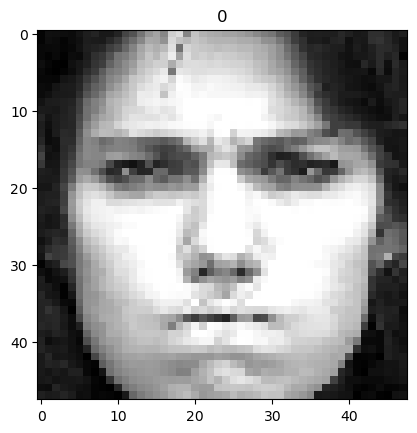

In [33]:
import matplotlib.pyplot as plt

plt.imshow(X_train[1].reshape(48,48), cmap='gray')
plt.title(y_train[1])
plt.show()

In [39]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [40]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(48,48,1)),
    # 第一層卷積 (提取特徵)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 第二層卷積
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 扁平化與全連接層
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # 投影片提到的解決 Overfitting 方法
    layers.Dense(8, activation='softmax') # 8 類情緒分類
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step


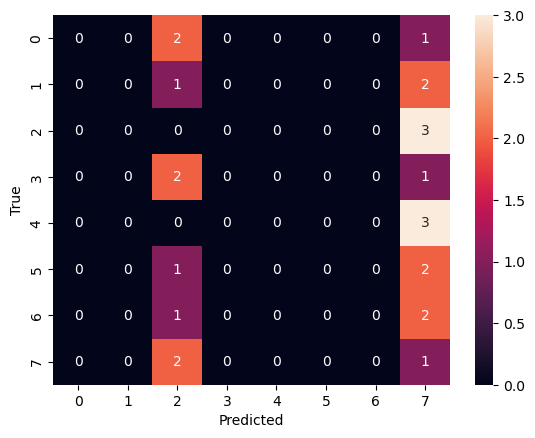

C:\Users\hsiao\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 256ms/step - accuracy: 0.6194 - loss: 1.6336 - val_accuracy: 0.1250 - val_loss: 2.0860 - learning_rate: 0.0010
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 215ms/step - accuracy: 0.6585 - loss: 1.2956 - val_accuracy: 0.1250 - val_loss: 2.0880 - learning_rate: 0.0010
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.6596 - loss: 1.2645 - val_accuracy: 0.1250 - val_loss: 2.0895 - learning_rate: 0.0010
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.6741 - loss: 1.1754 - val_accuracy: 0.1250 - val_loss: 2.0497 - learning_rate: 0.0010
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 242ms/step - accuracy: 0.7165 - loss: 1.0761 - val_accuracy: 0.1667 - val_loss: 2.0270 - learning_rate: 0.0010
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 246ms/step - accuracy: 0.7277 - loss: 0.9793 - val_accuracy: 0.2500 - val_loss: 1.9441 - learning_rate: 0.0010
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step - accuracy: 0.7522 - loss: 0.8950 -

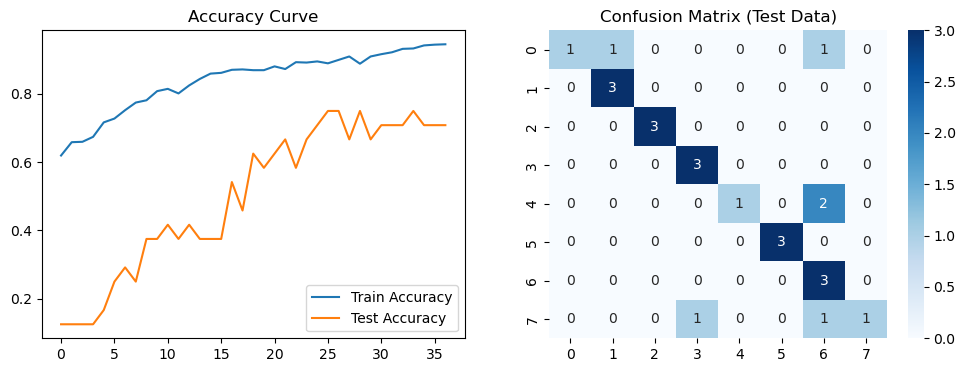

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7500 - loss: 0.9138

最終測試資料正確率: 75.00%


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. 資料讀取與預處理 [cite: 9]
df = pd.read_csv(r"C:\cnn_project\CK+ Dataset.csv") # 請確認路徑正確

def parse_pixels(pixel_str):
    return np.array(pixel_str.split(), dtype='float32').reshape(48, 48, 1)

df['pixel_matrix'] = df['pixels'].apply(parse_pixels)

# 2. 嚴格遵守切割規則：每類最後 3 張為測試 
train_data, test_data = [], []
train_labels, test_labels = [], []

for emotion_id in range(8):
    emotion_df = df[df['emotion'] == emotion_id]
    test_subset = emotion_df.tail(3)
    train_subset = emotion_df.iloc[:-3]
    
    test_data.extend(test_subset['pixel_matrix'].values)
    test_labels.extend(test_subset['emotion'].values)
    train_data.extend(train_subset['pixel_matrix'].values)
    train_labels.extend(train_subset['emotion'].values)

# 歸一化 (Normalize) [cite: 9]
X_train = np.array(train_data) / 255.0
X_test = np.array(test_data) / 255.0
y_train = np.array(train_labels)
y_test = np.array(test_labels)

# 3. 建立 CNN 模型 (符合：Conv → ReLU → Pooling → FC → Softmax) 
model = models.Sequential([
    # 第一層卷積與池化 
    layers.Conv2D(64, (3, 3), padding='same', input_shape=(48, 48, 1)),
    layers.BatchNormalization(), # 增加穩定性
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 第二層卷積與池化
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 第三層卷積 (學習更複雜影像特徵) [cite: 13]
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 全連接層 (FC) 
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # 解決 Overfitting 
    layers.Dense(8, activation='softmax') # 8 類情緒分類 
])

# 設定損失函數：Cross Entropy [cite: 12, 20]
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. 訓練優化策略 (Augmentation & Callbacks) 
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# 自動止損與降低學習率
early_stop = callbacks.EarlyStopping(patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(factor=0.2, patience=5)

# 5. 開始訓練 [cite: 21]
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
)

# 6. 產出報告所需的評估結果 
# 學習曲線 [cite: 22]
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# 混淆矩陣 (Confusion Matrix) 
y_pred = model.predict(X_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Data)')
plt.show()

# 顯示最終測試正確率 [cite: 25]
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n最終測試資料正確率: {test_acc*100:.2f}%")

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 254ms/step - accuracy: 0.0993 - loss: 2.3703 - val_accuracy: 0.1250 - val_loss: 2.0795 - learning_rate: 0.0010
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 235ms/step - accuracy: 0.4018 - loss: 2.0740 - val_accuracy: 0.1250 - val_loss: 2.0794 - learning_rate: 0.0010
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.2801 - loss: 2.0499 - val_accuracy: 0.2083 - val_loss: 2.0777 - learning_rate: 0.0010
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 274ms/step - accuracy: 0.1920 - loss: 2.0635 - val_accuracy: 0.1667 - val_loss: 2.0746 - learning_rate: 0.0010
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 247ms/step - accuracy: 0.2935 - loss: 1.9650 - val_accuracy: 0.2917 - val_loss: 2.0588 - learning_rate: 0.0010
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 256ms/step - accuracy: 0.2277 - loss: 1.8581 - val_accuracy: 0.2500 - val_loss: 2.0632 - learning_rate: 0.0010
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 260ms/step - accuracy: 0.2489 - loss: 1.7986 -

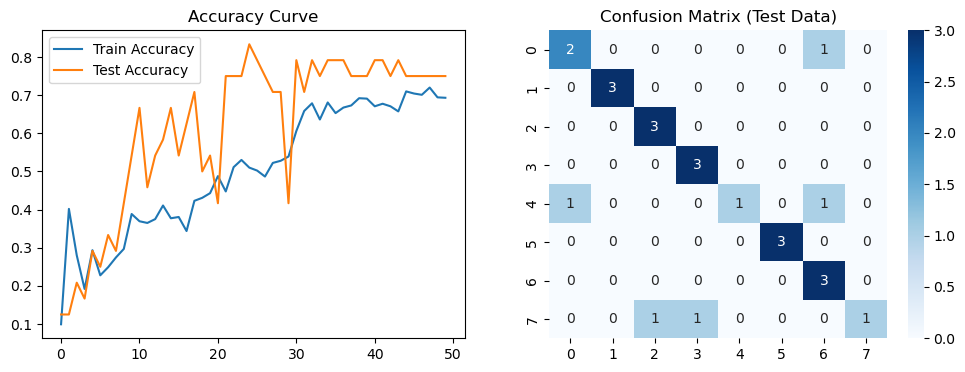

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7917 - loss: 0.7559

最終測試資料正確率: 79.17%


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. 資料讀取與預處理 [cite: 9]
df = pd.read_csv(r"C:\cnn_project\CK+ Dataset.csv") # 請確認路徑正確

def parse_pixels(pixel_str):
    return np.array(pixel_str.split(), dtype='float32').reshape(48, 48, 1)

df['pixel_matrix'] = df['pixels'].apply(parse_pixels)

# 2. 嚴格遵守切割規則：每類最後 3 張為測試 
train_data, test_data = [], []
train_labels, test_labels = [], []

for emotion_id in range(8):
    emotion_df = df[df['emotion'] == emotion_id]
    test_subset = emotion_df.tail(3)
    train_subset = emotion_df.iloc[:-3]
    
    test_data.extend(test_subset['pixel_matrix'].values)
    test_labels.extend(test_subset['emotion'].values)
    train_data.extend(train_subset['pixel_matrix'].values)
    train_labels.extend(train_subset['emotion'].values)

# 歸一化 (Normalize) [cite: 9]
X_train = np.array(train_data) / 255.0
X_test = np.array(test_data) / 255.0
y_train = np.array(train_labels)
y_test = np.array(test_labels)

# 3. 建立 CNN 模型 (符合：Conv → ReLU → Pooling → FC → Softmax) 
model = models.Sequential([

    layers.Input(shape=(48,48,1)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(128, (3,3),
                  padding='same',
                  activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(256, (3,3),
                  padding='same',
                  activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    # 增強防 overfitting
    layers.Dropout(0.6),

    layers.Dense(8, activation='softmax')
])

# 設定損失函數：Cross Entropy [cite: 12, 20]
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. 訓練優化策略 (Augmentation & Callbacks) 
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# 自動止損與降低學習率
early_stop = callbacks.EarlyStopping(patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(factor=0.2, patience=5)

# 5. 開始訓練 [cite: 21]
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# 6. 產出報告所需的評估結果 
# 學習曲線 [cite: 22]
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# 混淆矩陣 (Confusion Matrix) 
y_pred = model.predict(X_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Data)')
plt.show()

# 顯示最終測試正確率 [cite: 25]
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n最終測試資料正確率: {test_acc*100:.2f}%")